# Used Car Price Prediction

## 1. Import Libraries

In [77]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load Dataset

In [8]:

DATA_PATH = "../data/raw/car details v4.csv"
cars=pd.read_csv(DATA_PATH)
df=cars.copy()

## 3. Initial Inspection

In [9]:
df.shape

(8128, 13)


- *Total observations:* 8,128  
- *Total features (columns):* 13

In [12]:
df.head().style.background_gradient(cmap='autumn')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.000000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.000000
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.000000
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.000000
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.000000


- *Total features:* 13
- *Categorical features:* 5 *(name , seller_type , fuel ,owner , transmission)*
- *Target feature:* selling_price


In [13]:
df.sample(5, random_state=42)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1971,Honda City 1.5 GXI,2004,198000,110000,Petrol,Individual,Manual,Third Owner,12.8 kmpl,1493 CC,100 bhp,13.1kgm@ 4600rpm,5.0
4664,Tata Safari Storme EX,2014,500000,291977,Diesel,Individual,Manual,First Owner,14.0 kmpl,2179 CC,138.1 bhp,320Nm@ 1700-2700rpm,7.0
5448,Maruti Ritz VDi,2016,425000,70000,Diesel,Individual,Manual,First Owner,23.2 kmpl,1248 CC,73.94 bhp,190Nm@ 2000rpm,5.0
3333,Honda City 2017-2020 VTEC,2006,150000,120000,Petrol,Individual,Manual,Second Owner,16.9 kmpl,1497 CC,100 bhp,"13.5@ 4,800(kgm@ rpm)",5.0
2316,Maruti Swift VDI,2013,525000,69000,Diesel,Individual,Manual,Second Owner,22.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0


*No inconsistencies found overall data looks normal*

## 4. Column Information

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


**Total entries:** 8128

**Total columns:** 13

**Missing values in**
- *Mileage , engine , max_power , torque ,seats*

In [16]:
df.columns.tolist()

['name',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage',
 'engine',
 'max_power',
 'torque',
 'seats']

## 5. Data Types

In [21]:
numeric_columns=df.select_dtypes(include=np.number).columns.tolist()

categorical_columns=df.select_dtypes(include=['object','str']).columns.tolist()

print('Numeric:', numeric_columns)
print('Categorical:', categorical_columns)

Numeric: ['year', 'selling_price', 'km_driven', 'seats']
Categorical: ['name', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque']


*Some columns are incorrectly classified as categorical features even though they contain numerical information. These columns should be converted to numeric types:*
- *mileage , engine , max_power , torque*

## 6. Missing Values

In [38]:
display(df.isnull().sum())
missing_percentage=df.isnull().mean().mul(100).round(2).sort_values(ascending=False)
missing_percentage

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

torque           2.73
seats            2.72
engine           2.72
mileage          2.72
max_power        2.65
fuel             0.00
km_driven        0.00
selling_price    0.00
year             0.00
name             0.00
owner            0.00
seller_type      0.00
transmission     0.00
dtype: float64

*Missing values found in columns:*
- **mileage:** 221
- **engine:** 221
- **max_power:** 215
- **torque:** 222
- **seats:** 221

<Axes: >

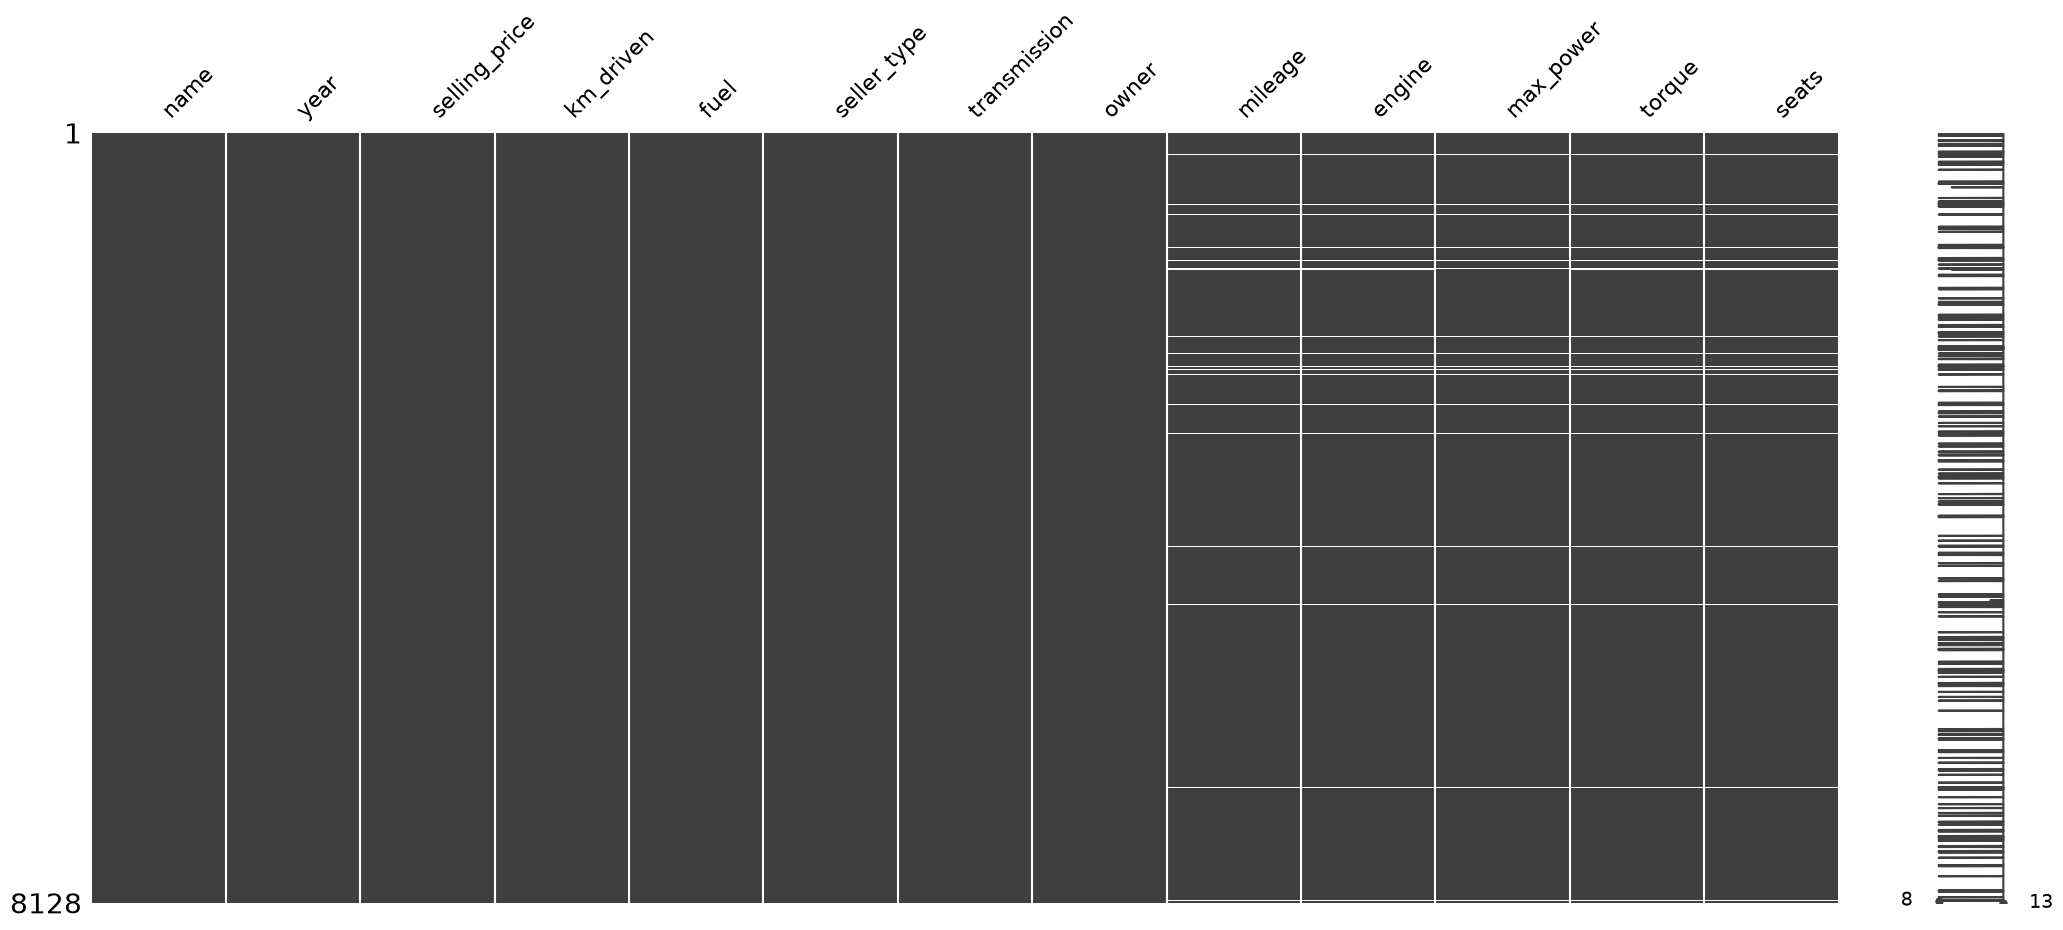

In [30]:
# Visualizing missing values using missingno
import missingno as msno

msno.matrix(df)

*There is a correlation between missing values , mileage,engine ,max_power , torque,seats are missing together in the entries*

<Axes: >

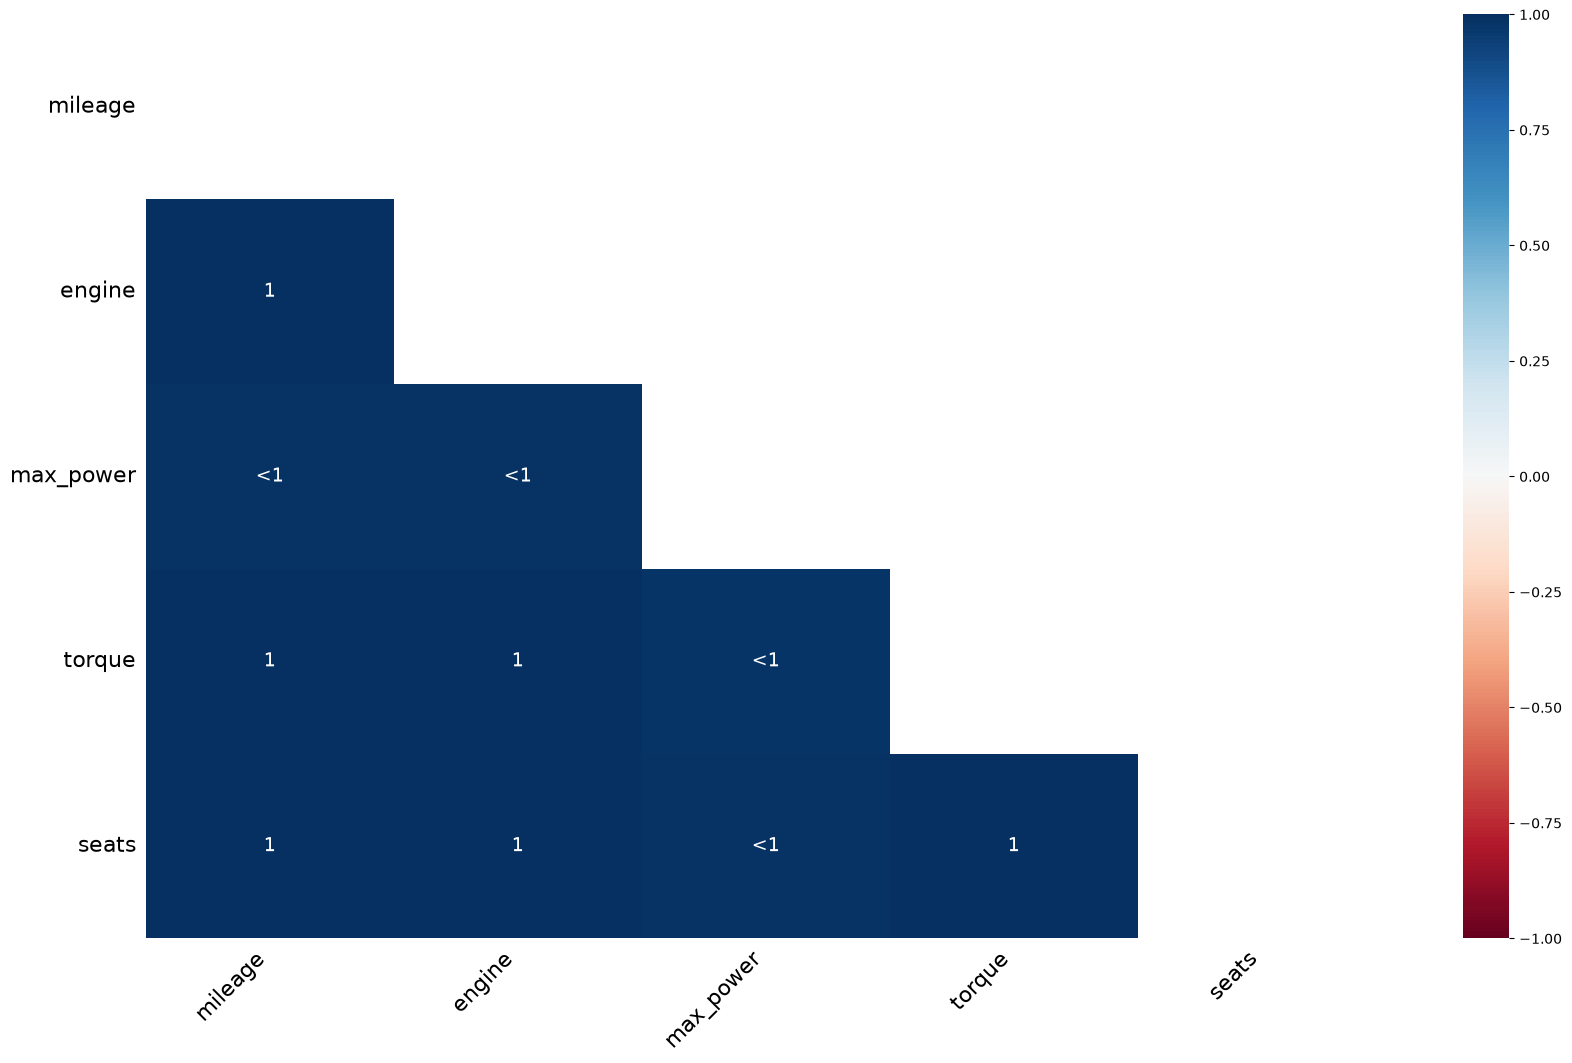

In [40]:
msno.heatmap(df)

## 7. Deuplicated Data

In [46]:

print("Deuplicated" , df.duplicated().sum())

Deuplicated 1202


*Duplicated Entries:* 1202

*We will inspect further to confirm if these are actual duplicated records*

In [78]:
duplicates=df[df.duplicated(keep=False)].value_counts()
display(duplicates[2:4])
df[df['name']=='Honda Jazz VX'].head(3)


name                     year  selling_price  km_driven  fuel    seller_type       transmission  owner        mileage     engine   max_power  torque          seats
Toyota Camry 2.5 Hybrid  2016  2000000        68089      Petrol  Trustmark Dealer  Automatic     First Owner  19.16 kmpl  2494 CC  157.7 bhp  213Nm@ 4500rpm  5.0      32
Honda Jazz VX            2016  550000         56494      Petrol  Trustmark Dealer  Manual        First Owner  18.2 kmpl   1199 CC  88.7 bhp   110Nm@ 4800rpm  5.0      32
Name: count, dtype: int64

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
378,Honda Jazz VX,2016,550000,56494,Petrol,Trustmark Dealer,Manual,First Owner,18.2 kmpl,1199 CC,88.7 bhp,110Nm@ 4800rpm,5.0
417,Honda Jazz VX,2016,550000,56494,Petrol,Trustmark Dealer,Manual,First Owner,18.2 kmpl,1199 CC,88.7 bhp,110Nm@ 4800rpm,5.0
654,Honda Jazz VX,2016,550000,56494,Petrol,Trustmark Dealer,Manual,First Owner,18.2 kmpl,1199 CC,88.7 bhp,110Nm@ 4800rpm,5.0


*Further analsis confirmed that these are actual duplicated entries and we have to remove them in data processing phase*

## 8. Summary Statistics

In [73]:
# numeric features
df.describe().style.background_gradient(cmap='copper')

,year,selling_price,km_driven,seats
count,8128.000000,8128.000000,8128.000000,7907.000000
mean,2013.804011,638271.807702,69819.510827,5.416719
std,4.044249,806253.403508,56550.554958,0.959588
min,1983.000000,29999.000000,1.000000,2.000000
25%,2011.000000,254999.000000,35000.000000,5.000000
50%,2015.000000,450000.000000,60000.000000,5.000000
75%,2017.000000,675000.000000,98000.000000,5.000000
max,2020.000000,10000000.000000,2360457.000000,14.000000


In [76]:
df.describe(include=['object','str'])

,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,8128,8128,8128,8128,8128,7907,7907,7913,7906
unique,2058,4,3,2,5,393,121,322,441
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,129,4402,6766,7078,5289,225,1017,377,530


In [101]:
# Checking Inconsistent labling in categorical features
cols=['fuel','seller_type','transmission','owner']
for col in cols:
    display(df[col].unique())

<StringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

<StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

<StringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

*The data is ranging between `1983` to `2020`*

*In selling price there is quite differnce between mean and midean as mean is considerably higher that means selling_price is right skewd , and can have potential outliers or small number of highley expensive vehicles*

*The **kilometers driven** range from **1 km** to **2,360,457 km**. The mean (**69,820 km**) is higher than the median (**60,000 km**), indicating that some vehicles have exceptionally high mileage. The maximum value is unusually large and should be investigated as a potential outlier.*

*The `mileage`, `engine`, `max_power`, and `torque` columns contain missing values and are stored as text because they include measurement units (such as kmpl, CC, bhp, and Nm). These features represent numerical information and should be cleaned and converted to appropriate numeric data types before further analysis*


## 9. Exploring Target 

In [133]:
pd.set_option('display.float_format', '{:,.2f}'.format)

print(df['selling_price'].describe())

count        8,128.00
mean       638,271.81
std        806,253.40
min         29,999.00
25%        254,999.00
50%        450,000.00
75%        675,000.00
max     10,000,000.00
Name: selling_price, dtype: float64


In [125]:
df['selling_price'].skew()

np.float64(4.193533440675855)

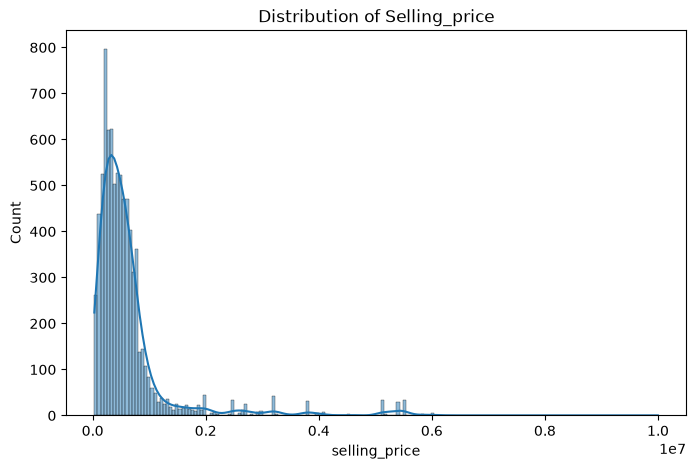

In [137]:

import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], kde=True)
plt.title('Distribution of Selling_price')
plt.show()

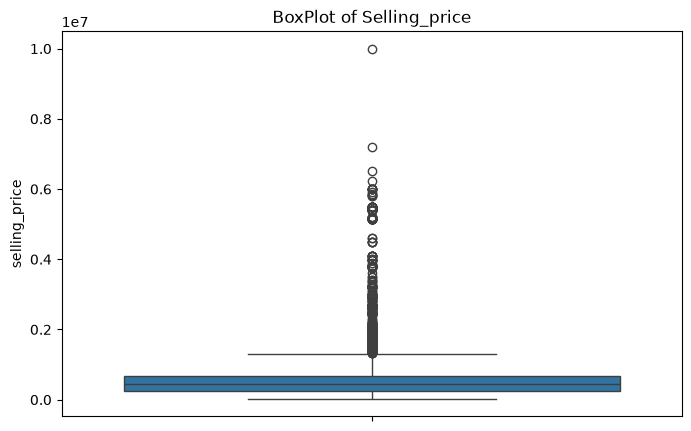

In [136]:
plt.figure(figsize=(8,5))
sns.boxplot(df['selling_price'])
plt.title('BoxPlot of Selling_price')
plt.show()


In [139]:
df['selling_price'].describe()

count        8,128.00
mean       638,271.81
std        806,253.40
min         29,999.00
25%        254,999.00
50%        450,000.00
75%        675,000.00
max     10,000,000.00
Name: selling_price, dtype: float64

**Selling Price:**
- *min:`29,999` max:`10,000,000` mean:`638,271` median:`450,000`*
- *The target variable has a skewness of `4.19`, indicating a strong positive (right) skew. This suggests that a relatively small number of expensive vehicles create a long right tail in the distribution*
- *Appling log transformation `log1p` makes sense beacuse the data is right skewed*
- *`Histogram`shows that most vehicles are concentrated in the lower price range, while a relatively small number of luxury vehicles form a long right tail  and `Boxplot ` points to some extreme outliers*

## Initial Observations

### Dataset Size
- Number of rows:`8128`
- Number of columns:`13`

### Target Variable
- Target column:`selling_price`
- Regression problem because... *The target `selling_price` is a continous value*

### Data Types
- Numeric columns:*The columns `mileage, engine, max_power, and torque` are stored as strings because they contain units (for example, "18.9 kmpl" or "1248 CC"). These columns should be cleaned and converted to numeric values during preprocessing.*
- Categorical columns:*There are originally `5` Categorical Columns*

### Missing Values
- Columns with missing values:*mileage:`221` , engine:`221` , max_power:`215` ,torque:`222` ,seats:`221`*
- Initial thoughts:*After visualizing missing values by using `missingno` the missing values are seem to be correlated strongly that means all of these values are missing together*

### Duplicate Records
- Number of duplicate rows:`1202`
- Action: Investigate in the cleaning phase.*The dataset contains rows that are identical across all recorded variables. However, we cannot conclude they are erroneous duplicates. They may represent legitimate repeated observations because the dataset lacks identifiers such as seller ID or listing ID. Therefore, duplicate rows should be investigated before any removal decision is made.*

### Potential Concerns
- High-cardinality categories? *name contains `2058` unique categories*
- Inconsistent labels?*No Inconsistent labeling found*
- Impossible values? *No suspicious looking data*
- Outliers?*There are outliers in selling_price and km_driven (but luxury vehicles can be highly expensive and sports cars can have high km_driven value)*
- Potential data leakage?*There is no data leakage found*